# Importing Libraries

In [11]:
import numpy as np
import h5py
import os
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.applications import VGG19
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
# Set dataset path
dataset_path = "/kaggle/input/figshare-braintumor/tumor"

# Function to load data and image preprocessing

In [13]:
def load_mat_data_v73(path):
    """Loads MRI images and labels from MATLAB v7.3 .mat files"""
    images = []
    labels = []
    
    for file in os.listdir(path):
        if file.endswith(".mat"):
            file_path = os.path.join(path, file)
            
            with h5py.File(file_path, "r") as mat:
                # Extract image
                img = np.array(mat["cjdata"]["image"])
                label = np.array(mat["cjdata"]["label"])[0, 0] - 1  # Convert to 0-indexed
                
                # Resize image for ConvNeXt (224x224)
                img_resized = cv2.resize(img, (224, 224))
                img_resized = img_resized / 255.0  # Normalize
                
                images.append(img_resized)
                labels.append(label)
    
    return np.array(images), np.array(labels)


# Loading Dataset

In [14]:
# Load dataset
X, y = load_mat_data_v73(dataset_path)

# Converting to RGB and one hot encoding labels

In [15]:
# Convert grayscale to RGB
X = np.expand_dims(X, axis=-1)  # Add channel dimension
X = np.repeat(X, 3, axis=-1)  # Convert grayscale to RGB

# Model

In [16]:
# Prepare for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
acc_per_fold = []
loss_per_fold = []
histories = []


Training fold #1
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.5656 - loss: 0.9432 - val_accuracy: 0.8208 - val_loss: 0.4812
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8278 - loss: 0.4316 - val_accuracy: 0.8473 - val_loss: 0.3793
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.8412 - loss: 0.3813 - val_accuracy: 0.8656 - val_loss: 0.3182
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8586 - loss: 0.3325 - val_accuracy: 0.8798 - val_loss: 0.3040
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8669 - loss: 0.3079 - val_accuracy: 0.8778 - val_loss: 0.2909
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8773 - loss: 0.2840 - val_accuracy: 0.8798 - val_loss: 0.2822
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8802 - loss: 0.3020 - val_accuracy: 0.8697 - val_loss: 0.2864
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.8903 - loss: 0.2704 - val_a

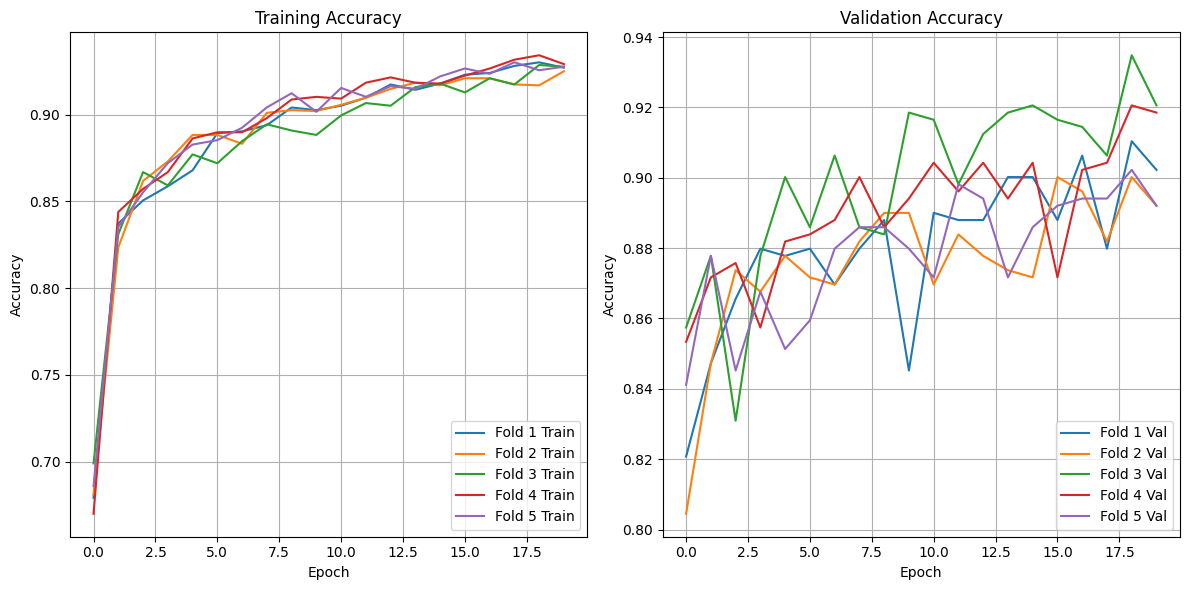

In [17]:
for train_index, test_index in skf.split(X, y):
    print(f'Training fold #{fold_no}')
    
    # Split data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # One-hot encode labels
    y_train = to_categorical(y_train, num_classes=3)
    y_test = to_categorical(y_test, num_classes=3)
    
    # Split train into train/validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    
    # Create model
    base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(3, activation="softmax")(x)
    
    model = keras.Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
   
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
    )
    histories.append(history.history)
    
    # Evaluate model
    scores = model.evaluate(X_test, y_test, verbose=0)
    print(f'Fold {fold_no} - Test loss: {scores[0]:.4f}, Test accuracy: {scores[1]:.4f}')
    
    acc_per_fold.append(scores[1])
    loss_per_fold.append(scores[0])
    fold_no += 1

# == Results Summary ==
print('\nCross-validation results:')
print(f'Accuracies: {[f"{acc:.4f}" for acc in acc_per_fold]}')
print(f'Losses: {[f"{loss:.4f}" for loss in loss_per_fold]}')
print(f'Average accuracy: {np.mean(acc_per_fold):.4f}')
print(f'Average loss: {np.mean(loss_per_fold):.4f}')

# == Visualization ==
plt.figure(figsize=(12, 6))
for i, history in enumerate(histories):
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label=f'Fold {i+1} Train')
    plt.subplot(1, 2, 2)
    plt.plot(history['val_accuracy'], label=f'Fold {i+1} Val')

plt.subplot(1, 2, 1)
plt.title('Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# Prediction

In [18]:
class_names = ["Meningioma", "Glioma", "Pituitary"]

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report (contains precision/recall/F1/accuracy)
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))

# Generate confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
class_accuracies = cm.diagonal()/cm.sum(axis=1)
print("\nClass Accuracies:")
for i, acc in enumerate(class_accuracies):
    print(f"Class {i}: {acc:.2%}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.67      0.74       141
           1       0.86      0.94      0.90       285
           2       0.97      0.96      0.97       186

    accuracy                           0.89       612
   macro avg       0.88      0.86      0.87       612
weighted avg       0.89      0.89      0.88       612


Class Accuracies:
Class 0: 67.38%
Class 1: 94.39%
Class 2: 96.24%


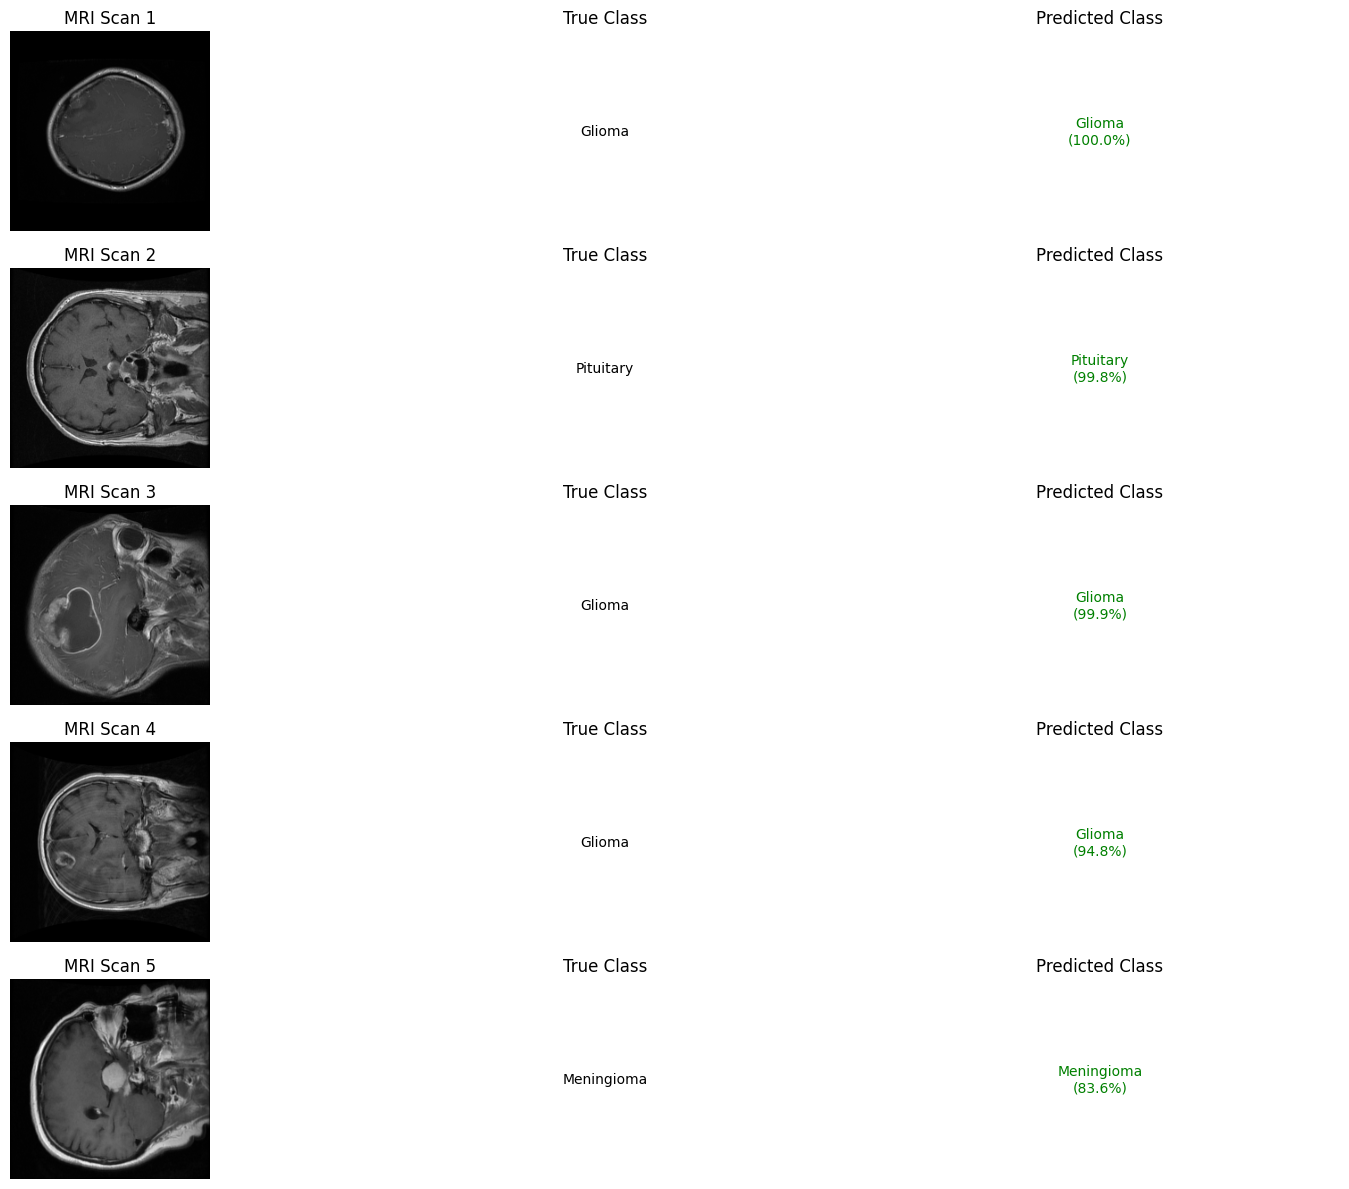

In [20]:
plt.figure(figsize=(15, 12))
for i in range(5):
    plt.subplot(5, 3, i*3+1)
    plt.imshow(X_test[i][:, :, 0], cmap='gray')  # Show first channel of RGB
    plt.title(f"MRI Scan {i+1}")
    plt.axis('off')
    
    plt.subplot(5, 3, i*3+2)
    plt.text(0.5, 0.5, class_names[y_true_classes[i]], 
             ha='center', va='center', fontsize=10)
    plt.title("True Class")
    plt.axis('off')
    
    plt.subplot(5, 3, i*3+3)
    confidence = np.max(y_pred_probs[i]) * 100
    color = 'green' if y_true_classes[i] == y_pred_classes[i] else 'red'
    plt.text(0.5, 0.5, f"{class_names[y_pred_classes[i]]}\n({confidence:.1f}%)", 
             ha='center', va='center', fontsize=10, color=color)
    plt.title("Predicted Class")
    plt.axis('off')

plt.tight_layout()
plt.show()